# Ch 17 — Reuters 뉴스 분류 (RNN/LSTM)

원본: `deep_code/15_Reuters_LSTM.py`

다루는 내용:
1. Reuters 데이터 로드 (정수로 인코딩된 시퀀스)
2. 시퀀스 길이 분포 + 클래스 분포 확인
3. `pad_sequences` 로 길이 통일
4. Embedding → LSTM → Dense(softmax) 모델
5. 학습 곡선 + 테스트 정확도
6. 디코딩: 정수 시퀀스 → 단어 → 예측 라벨

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Embedding, LSTM, Dense
from keras.utils import pad_sequences

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

2026-05-14 13:16:58.117040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778732218.145212 2258131 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778732218.154077 2258131 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터 로드

`num_words=1000` 이면 빈도 상위 1,000개 단어만 사용. 나머지는 OOV 토큰으로 처리됨.
각 기사는 단어 인덱스 시퀀스로 이미 인코딩되어 있음 — 토크나이징·정제 불필요.

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.reuters.load_data(num_words=1000)
print("X_train 개수:", len(X_train))
print("X_test  개수:", len(X_test))
print("클래스 수:", len(np.unique(y_train)))
print("\n첫 기사 (정수 시퀀스, 길이 %d):" % len(X_train[0]))
print(X_train[0][:30], "...")
print("\n첫 기사 라벨:", y_train[0])

X_train 개수: 8982
X_test  개수: 2246
클래스 수: 46

첫 기사 (정수 시퀀스, 길이 87):
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 2, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67] ...

첫 기사 라벨: 3


## 2. 시퀀스 길이 분포

평균 146 / 중앙값 95 / 최소 13 / 최대 2376
100단어 이하 비율: 53.8%


/tmp/ipykernel_2258131/2692582868.py:14: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2258131/2692582868.py:14: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2258131/2692582868.py:14: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2258131/2692582868.py:14: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2258131/2692582868.py:14: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2258131/2692582868.py:14: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2258131/2692582868.py:14: UserWarnin

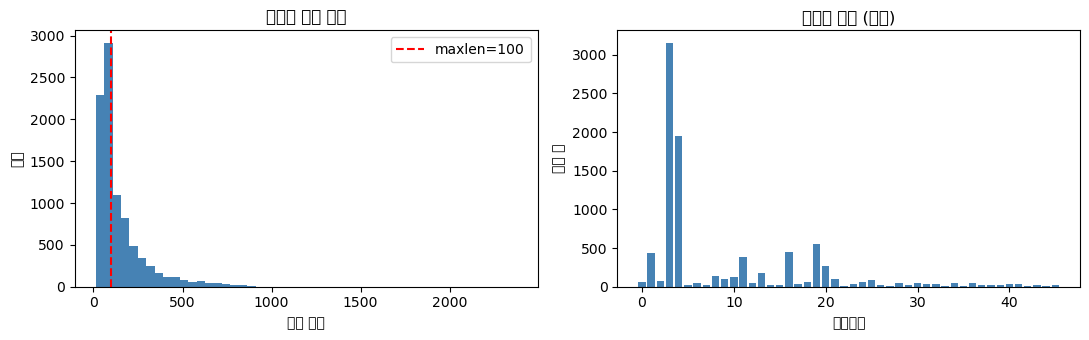

In [3]:
lengths = np.array([len(s) for s in X_train])
print(f"평균 {lengths.mean():.0f} / 중앙값 {np.median(lengths):.0f} / 최소 {lengths.min()} / 최대 {lengths.max()}")
print(f"100단어 이하 비율: {(lengths <= 100).mean()*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(lengths, bins=50, color="steelblue")
ax[0].axvline(100, color="red", linestyle="--", label="maxlen=100")
ax[0].set_xlabel("기사 길이"); ax[0].set_ylabel("개수"); ax[0].legend()
ax[0].set_title("시퀀스 길이 분포")

ax[1].bar(range(46), np.bincount(y_train, minlength=46), color="steelblue")
ax[1].set_xlabel("카테고리"); ax[1].set_ylabel("기사 수")
ax[1].set_title("클래스 분포 (학습)")
plt.tight_layout(); plt.show()

**관찰**: 클래스가 매우 불균형 (다수클래스 baseline 약 36%). 길이는 대부분 100단어 이하.

## 3. 시퀀스 길이 통일 — `pad_sequences`

LSTM 도 가변 길이를 받을 수 있지만 배치 학습엔 같은 길이가 편함. `maxlen=100` 으로 자르고 짧으면 0으로 패딩.

In [4]:
X_train = pad_sequences(X_train, maxlen=100)
X_test  = pad_sequences(X_test,  maxlen=100)
print("X_train:", X_train.shape, X_train.dtype)
print("X_test :", X_test.shape)
print("\n첫 기사 (패딩 후, 앞쪽 0 은 패딩):")
print(X_train[0])

X_train: (8982, 100) int32
X_test : (2246, 100)

첫 기사 (패딩 후, 앞쪽 0 은 패딩):
[  0   0   0   0   0   0   0   0   0   0   0   0   0   1   2   2   8  43
  10 447   5  25 207 270   5   2 111  16 369 186  90  67   7  89   5  19
 102   6  19 124  15  90  67  84  22 482  26   7  48   4  49   8 864  39
 209 154   6 151   6  83  11  15  22 155  11  15   7  48   9   2   2 504
   6 258   6 272  11  15  22 134  44  11  15  16   8 197   2  90  67  52
  29 209  30  32 132   6 109  15  17  12]


## 4. 모델 — Embedding + LSTM

```
Input(100,)                   # 정수 시퀀스
 → Embedding(1000, 100)       # (100, 100)  단어 → 100차 벡터
 → LSTM(100)                  # (100,)      마지막 hidden state
 → Dense(46, softmax)
```

In [5]:
keras.utils.set_random_seed(0)
model = Sequential([
    Input(shape=(100,)),
    Embedding(input_dim=1000, output_dim=100),
    LSTM(100),
    Dense(46, activation="softmax"),
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)
model.summary()

2026-05-14 13:17:01.940070: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       100,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 46)             │         4,646 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,046 (722.84 KB)

 Trainable params: 185,046 (722.84 KB)

 Non-trainable params: 0 (0.00 B)

## 5. 학습

In [6]:
hist = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=100,
    verbose=1,
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.3666 - loss: 2.5896 - val_accuracy: 0.4769 - val_loss: 2.1501
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.4868 - loss: 2.0635 - val_accuracy: 0.4814 - val_loss: 2.0110
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.5104 - loss: 1.8934 - val_accuracy: 0.5593 - val_loss: 1.7777
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.5479 - loss: 1.7640 - val_accuracy: 0.5637 - val_loss: 1.7202
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.5756 - loss: 1.6592 - val_accuracy: 0.5932 - val_loss: 1.6313
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.6017 - loss: 1.5873 - val_accuracy: 0.6027 - val_loss: 1.6109
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.6263 - loss: 1.4988 - val_accuracy: 0.6244 - val_loss: 1.5400
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.6523 - loss: 1.4177 - val_accu

## 6. 학습 곡선

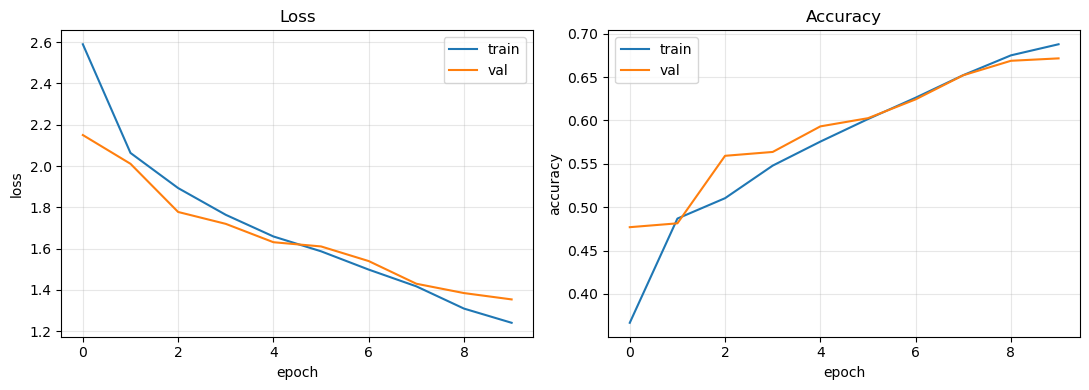

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist.history["loss"], label="train")
ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("Loss")

ax[1].plot(hist.history["accuracy"], label="train")
ax[1].plot(hist.history["val_accuracy"], label="val")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[1].set_title("Accuracy")
plt.tight_layout(); plt.show()

## 7. 테스트셋 평가

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
baseline = np.bincount(y_test).max() / len(y_test)
print(f"test loss     : {test_loss:.4f}")
print(f"test accuracy : {test_acc:.4f}")
print(f"baseline (다수클래스) : {baseline:.4f}")

test loss     : 1.3878
test accuracy : 0.6514
baseline (다수클래스) : 0.3620


## 8. 디코딩 — 정수 시퀀스를 다시 읽어보기

`reuters.get_word_index()` 가 단어→정수 사전을 줌. 거꾸로 뒤집어서 정수→단어 매핑.

In [9]:
word_index = keras.datasets.reuters.get_word_index()
# 인덱스는 1부터 시작. 0/1/2는 예약 토큰 (pad/start/unk)
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"

def decode(seq):
    return " ".join(index_to_word.get(i, "?") for i in seq if i != 0)

probs = model.predict(X_test[:3], verbose=0)
preds = np.argmax(probs, axis=1)
for i in range(3):
    print(f"--- 기사 {i} ---")
    print("내용:", decode(X_test[i])[:200], "...")
    print(f"예측: 카테고리 {preds[i]} (확률 {probs[i][preds[i]]:.2f})  /  정답: {y_test[i]}")
    print()

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- 기사 0 ---
내용: of <UNK> in august 1986 and <UNK> in december <UNK> us <UNK> better than expected results in the fourth quarter ended february 28 its net income from continuing operations <UNK> 52 6 pct to 20 7 mln d ...
예측: 카테고리 3 (확률 0.88)  /  정답: 3

--- 기사 1 ---
내용: without any <UNK> <UNK> was <UNK> <UNK> <UNK> <UNK> to cut domestic support prices to 12 cents a <UNK> from 18 cents the u s agriculture department last december <UNK> its 12 month 1987 sugar import q ...
예측: 카테고리 1 (확률 0.24)  /  정답: 10

--- 기사 2 ---
내용: for a month and we don't think it's going to get back in line in any <UNK> time <UNK> said <UNK> said usda will probably <UNK> back the gulf <UNK> when and if gulf prices <UNK> if <UNK> off the mark n ...
예측: 카테고리 11 (확률 0.42)  /  정답: 1



## 마무리 체크리스트
- [ ] `model.summary()` 에서 Embedding output shape 가 `(None, 100, 100)` 인지 — (배치, 시퀀스, 임베딩차원)
- [ ] LSTM output shape 가 `(None, 100)` 인지 — 마지막 hidden state 만
- [ ] test accuracy 가 baseline (~0.36) 보다 훨씬 위에 있는지 — LSTM 이 실제로 시퀀스를 배우고 있다는 증거
- [ ] 학습 곡선에서 train/val 격차 — RNN 은 과적합이 빠르게 옴. 격차 크면 epoch 줄이거나 Dropout 추가
- [ ] 디코딩 출력에서 `<UNK>` 가 많이 보이는지 — `num_words=1000` 이라 단어 대부분이 미지의 토큰. 늘리면 모델이 더 풍부한 정보를 받음 (대신 임베딩 크기도 증가)